### LASSO Activity

#### Predictive Modeling of $f(x)$

You are interested in learning about a function $f(x)$. However, you cannot observe $f(x)$ directly, but rather observe only a noisy version. In other words, when you plug in a value for $x$ you observe $f(x)$ plus some noise:

$$y_i=f(x_i) + \varepsilon_i$$

You have obtained 10 pairs of data points $(x_1, y_1), (x_2, y_2), \dots, (x_{10}, y_{10})$.

```python
df = pd.DataFrame({
   "x": [-1, -0.78, -0.56, -0.33, -0.11, 0.11, 0.33, 0.56, 0.78, 1],
   "y": [-1.09, -0.19, 0.04, 1.07, 1.98, 2.32, 1.63, 1.98, 1.11, 1.37]
})
```

Create a plot to investigate the relationship between `x` and `y`. What do you observe?

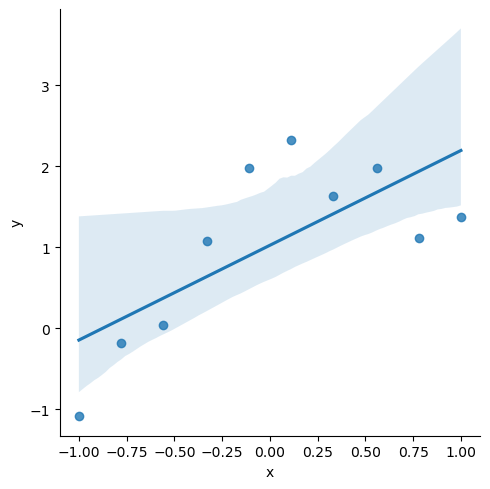

In [1]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame({
   "x": [-1, -0.78, -0.56, -0.33, -0.11, 0.11, 0.33, 0.56, 0.78, 1],
   "y": [-1.09, -0.19, 0.04, 1.07, 1.98, 2.32, 1.63, 1.98, 1.11, 1.37]
})

sns.lmplot(data=df, x="x", y="y")

The relationship looks almost linear, but there appears to be some nonlinearity as well.

#### Estimating $f(x)$ Using Simple Linear Regression

Now, fit a simple linear regression model for `x` and `y`. Look at the residuals of this model. What do you observe?

<Axes: ylabel='y'>

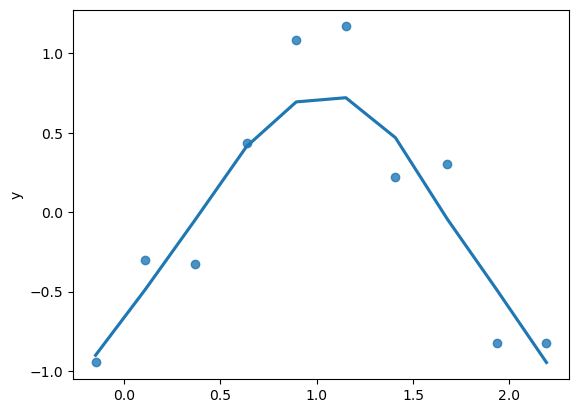

In [2]:
from sklearn.linear_model import LinearRegression

slr_model = LinearRegression()

X = df[["x"]]
y = df["y"]

slr_model.fit(X, y)

slr_preds = slr_model.predict(X)
slr_resids = y - slr_preds

sns.regplot(x=slr_preds, y=slr_resids, lowess=True)

The residuals indicate there is a quadratic trend not being captured by our simple linear regression model.

#### Estimating $f(x)$ Using Polynomial Regression Models

You want to see if you can find a model that can be used to perfectly predict `y` from `x`. You decide to fit models of the following form:

$$y_i = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_n x^n + \varepsilon_i$$

Start fitting these models, first with $n=1$ (simple linear regression) all the way until $n=9$. Record your observations about the following:

- What do you notice happens to the RMSE as you add more parameters?
- What do you notice about your estimates for the coefficients as you add more parameters?

<Axes: >

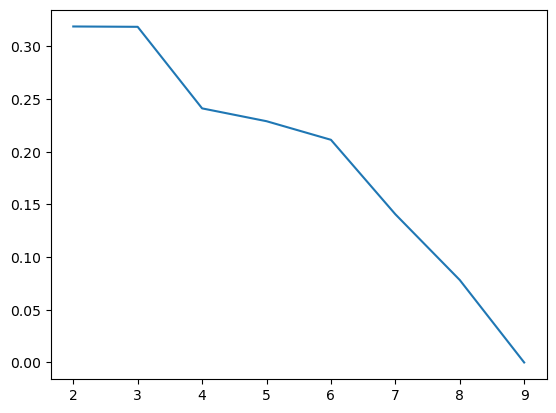

In [3]:
import numpy as np
from sklearn.metrics import root_mean_squared_error

for i in range(2, 10):
    df["x"+str(i)]=df["x"]**i

poly_model = LinearRegression()
rmse_values = []
coef_values = {}
intercept_values = {}
coef_abs_sum = []
predictors = ["x"]
y = df["y"]

for i in range(2, 10):
    predictors = ["x"] + ["x"+str(j) for j in range(2,i+1)]
    X = df[predictors]
    poly_model.fit(X, y)
    poly_preds = poly_model.predict(X)
    rmse_values.append(root_mean_squared_error(y, poly_preds))
    coef_abs_sum.append(np.abs(poly_model.coef_).sum())
    intercept_values["model"+str(i)] = poly_model.intercept_
    coef_values["model"+str(i)] = poly_model.coef_

sns.lineplot(x=np.arange(2, 10, 1), y=rmse_values)

[ 1.17048458 -1.82477747]
[ 1.22473425 -1.82477747 -0.07486119]
[ 1.22473425 -3.94219234 -0.07486119  2.09576784]
[ 1.71453865 -3.94219234 -2.09074528  2.09576784  1.57782148]
[ 1.71453865 -6.19779629 -2.09074528  8.33717655  1.57782148 -4.13122971]
[  0.10017951  -6.19779629  12.45507455   8.33717655 -29.53342073
  -4.13122971  18.20702477]
[  0.10017951 -13.3576468   12.45507455  50.33387395 -29.53342073
 -79.21702192  18.20702477  40.07639714]
[   1.74809713  -13.3576468   -18.06282942   50.33387395  111.20799568
  -79.21702192 -207.01306366   40.07639714  113.34980027]


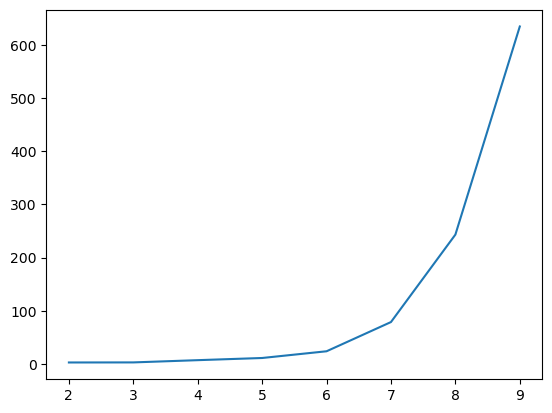

In [4]:
sns.lineplot(x=np.arange(2, 10, 1), y=coef_abs_sum)

for i in range(2, 10):
    print(coef_values["model"+str(i)])

The RMSE always decreases. The coefficients get larger and larger as we add more predictors to the model.

#### Comparing Different Estimates of $f(x)$

Consider the model for $n=2$ as well as the model for $n=9$. Plot these functions across a range of values from -1 to 1. Record your observations about the following:

- What do you notice about the difference between the two functions?
- Why do you think they are different?

<Axes: xlabel='x', ylabel='y'>

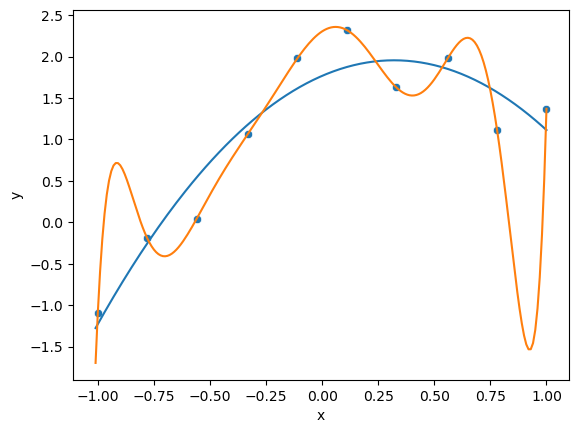

In [5]:
m2_b0 = intercept_values["model2"]
m2_coef = coef_values["model2"]

m9_b0 = intercept_values["model9"]
m9_coef = coef_values["model9"]

def f2(x, m2_b0, m2_coef):
    val = m2_b0 + m2_coef[0]*x + m2_coef[1]*x**2
    return val

def f9(x, m9_b0, m9_coef):
    val = (m9_b0 + m9_coef[0]*x + m9_coef[1]*x**2 + m9_coef[2]*x**3 + m9_coef[3]*x**4 +
           m9_coef[4]*x**5 + m9_coef[5]*x**6 + m9_coef[6]*x**7 + m9_coef[7]*x**8 + m9_coef[8]*x**9)
    return val

x_seq = np.arange(-1.01, 1.01, 0.01)

y2 = f2(x_seq, m2_b0, m2_coef)
y9 = f9(x_seq, m9_b0, m9_coef)

sns.scatterplot(df, x="x", y="y")
sns.lineplot(x=x_seq, y=y2) 
sns.lineplot(x=x_seq, y=y9)

The model with more predictors and higher-order polynomials fits the data perfectly, but is very flexible ("wiggly"). The model with just the linear and quadratic terms doesn't fit the data perfectly, but captures the overall trend well. It is also smoother and seems more stable.

#### Predicting New Observations

You've been given another set of observations:

```python
df_test = pd.DataFrame({
   "x_test": [-0.9, -0.7, -0.5, -0.3, -0.1, 0.1, 0.3, 0.5, 0.7, 0.9],
   "y_test": [-0.08, 0.59, 0.78, 1.94, 2.22, 2.16, 1.75, 2.1, 2.49, 1.95]
})
```

You would like to test your models on this new set of observations. For each of the models where $n=1$ to $n=9$, obtain predictions for `y_test` using `x_test`. Record your observations about the following:

- What happens to your predictions for the new observations?
- Why do you think this is happening?
- Which of the models appears to be best for predicting these new observations?

In [6]:
# YOUR CODE FOR GETTING PREDICTIONS FOR NEW OBSERVATIONS HERE

YOUR OBSERVATIONS HERE

#### LASSO Criterion Function

Until now you have been fitting models by focusing solely on finding estimates of model parameters that minimize RMSE:

$$\frac{1}{n} \sum_{i=1}^n \left(y_i - \hat{y}_i \right)^2$$

You hear about LASSO regression and learn that it seeks to find estimates of model parameters that that minimize the following:

$$\frac{1}{n} \sum_{i=1}^n \left(y_i - \hat{y}_i \right)^2 + \alpha \sum_{j=1}^J \lvert \beta_j \rvert$$

Using `x` and `y`, fit regression models again. For each of the models that you fit, instead of computing RMSE, compute the error function for LASSO regression. For now, try small values of $\alpha$ like $\alpha = 0.05$ or $\alpha = 0.1$. Record your observations about the following:

- What happens to this new quantity as you add more parameters?
- Why do you think this is happening?

In [7]:
# YOUR CODE FOR FITTING THE MODELS AND COMPUTING THE LASSO CRITERION HERE

YOUR OBSERVATIONS HERE

#### Role of $\alpha$ in LASSO Criterion Function

Now, do the same thing as before, but try picking new values for $\alpha$. Record your observations about the following:

- What do you notice happens as you increase $\alpha$?
- What do you think would happen if $\alpha=0$?

In [8]:
# YOUR CODE FOR FITTING MODELS WITH NEW VALUES OF ALPHA

YOUR OBSERVATIONS HERE

#### Predicting New Observations, Revisited

Consider one of the models for which the LASSO regression criterion function was small. Now, use this model to get predictions for `y_test` given `x_test`. Record your observations about the following:

- How well does this model predict new observations?
- If you had to choose a model to predict the new set of observations, what model would you choose?

In [9]:
# YOUR CODE FOR GETTING PREDICTIONS

YOUR OBSERVATIONS HERE

#### Applying Findings to New Scenarios

Now, consider the data found in `fuel.csv`.

- Based on what you have observed, what do you think would happen if you fit a model to predict fuel consumption using all available quantitative and categorical predictors available to you?
- Based on what you have observed, what might you do instead when trying to find a model that will predict future fuel consumption values well?

YOUR ANSWERS HERE